<a href="https://colab.research.google.com/github/nielitropar/computer-vision/blob/main/Fashion_MNIST_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST with Custom Image Testing

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Load dataset
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
# Normalize
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
# Model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train
model.fit(train_images, train_labels, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8209 - loss: 0.5071 - val_accuracy: 0.8552 - val_loss: 0.3977
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8635 - loss: 0.3809 - val_accuracy: 0.8698 - val_loss: 0.3584
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8762 - loss: 0.3390 - val_accuracy: 0.8665 - val_loss: 0.3674
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8863 - loss: 0.3138 - val_accuracy: 0.8698 - val_loss: 0.3502
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8909 - loss: 0.2955 - val_accuracy: 0.8778 - val_loss: 0.3367
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8947 - loss: 0.2823 - val_accuracy: 0.8768 - val_loss: 0.3346
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9014 - loss: 0.2678 - val_accuracy: 0.8835 - val_loss: 0.3270
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9046 - loss: 0.2563 - 

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8807 - loss: 0.3570
Test accuracy: 0.8806999921798706


## Test on Custom Image

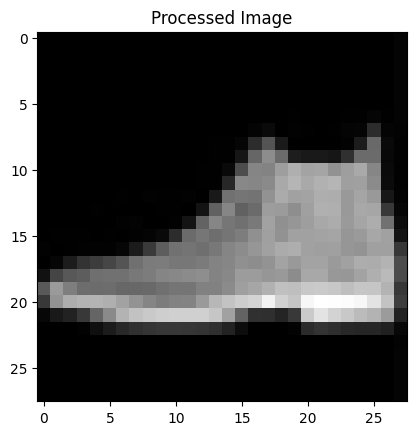

In [ ]:
# Load your image here (replace filename)
img_path = 'test.png'  # <-- put your image file here

img = Image.open(img_path).convert('L')  # grayscale
img = img.resize((28, 28))

img_array = np.array(img)

# Invert colors if background is white
# img_array = 255 - img_array

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img_array[0], cmap='gray')
plt.title('Processed Image')
plt.show()

In [ ]:
# Predict
pred = model.predict(img_array)
print('Prediction:', class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Prediction: Ankle boot
